In [1]:
import numpy as np
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import copy

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch


In [2]:
# Weighted adjacency matrix
# K = np.array([
#     [0,   0.8, 0.4, 0  ],
#     [0.8, 0,   1.0, 0.2],
#     [0.4, 1.0, 0,   0.7],
#     [0,   0.2, 0.7, 0  ]
# ])
W = np.array([[0, 1, 1, 0], 
              [1, 0, 1, 1], 
              [1, 1, 0, 1], 
              [0, 1, 1, 0], 
])

target_edge_nodes = (1,2)
source = 0
sink = 3


# # make W for network with nodes 1-6, connections: 0-2,0-3,1-3,1-4,2-3,3-4,2-5,3-5,3-6,4-6,5-6
# W = np.array([[0, 1, 1, 1, 0, 0, 0], 
#               [1, 0, 0, 1, 1, 0, 0], 
#               [1, 0, 0, 1, 0, 1, 0], 
#               [1, 1, 1, 0, 1, 1, 1], 
#               [0, 1, 0, 1, 0, 0, 1], 
#               [0, 0, 1, 1, 0, 0, 1], 
#               [0, 0, 0, 1, 1, 1, 0],
# ])
# target_edge_nodes = (5, 6)


# Build weighted graph
G = nx.from_numpy_array(W)

# Incidence matrix B (edges x nodes)
B = - nx.incidence_matrix(G, oriented=True).toarray()
print("Incidence matrix B:\n", B)

# Diagonal matrix of conductances
edges = list(G.edges())
K = np.diag([G[u][v]['weight'] for u, v in edges])
print("Diagonal conductance matrix K:\n", K)

# Weighted Laplacian (D is now sum of weights per node)
L_weighted = nx.laplacian_matrix(G).toarray()
L_pinv = np.linalg.pinv(L_weighted)

print("Weighted Laplacian L:\n", L_weighted)


Incidence matrix B:
 [[ 1.  1. -0. -0. -0.]
 [-1. -0.  1.  1. -0.]
 [-0. -1. -1. -0.  1.]
 [-0. -0. -0. -1. -1.]]
Diagonal conductance matrix K:
 [[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]
Weighted Laplacian L:
 [[ 2 -1 -1  0]
 [-1  3 -1 -1]
 [-1 -1  3 -1]
 [ 0 -1 -1  2]]


In [3]:


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: draw a single graph panel
# ─────────────────────────────────────────────────────────────────────────────

from matplotlib.pyplot import tick_params


def _draw_panel(ax, G, pos, norm_values, cmap,
                signed=False, directions=None):
    """
    Draw one graph panel onto `ax`.

    Parameters
    ----------
    ax          : matplotlib Axes
    G           : networkx graph
    pos         : node positions dict
    norm_values : array in [0,1] for color + width encoding
    cmap        : colormap
    signed      : whether to flip arrow direction by sign
    directions  : array of +1/-1 per edge (required if signed=True)
    """
    edge_colors = cmap(norm_values)
    edge_widths = 1 + 4 * norm_values
    edges = list(G.edges())

    if not signed:
        nx.draw(
            G, pos, ax=ax,
            with_labels=True,
            node_color='steelblue',
            node_size=800,
            font_color='white',
            font_size=14,
            edge_color=edge_colors,
            width=edge_widths,
        )
    else:
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color='steelblue', node_size=800)
        nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_size=14)

        for i, (u, v) in enumerate(edges):
            src, dst = (u, v) if directions[i] >= 0 else (v, u)
            ax.add_patch(FancyArrowPatch(
                posA=pos[src], posB=pos[dst],
                arrowstyle='-|>',
                color=edge_colors[i],
                linewidth=edge_widths[i],
                mutation_scale=20,
                connectionstyle='arc3,rad=0.08',
                shrinkA=18, shrinkB=18,
                zorder=2,
            ))

    ax.set_axis_off()


# ─────────────────────────────────────────────────────────────────────────────
# HELPER: prepare values (sign split, log, normalize)
# ─────────────────────────────────────────────────────────────────────────────

def _prepare_values(values, cmap, signed, log_scale, label):
    """
    Returns (plot_values, norm_values, v_min, v_max, cbar_label, directions, cmap).
    """
    values = np.array(values, dtype=float)

    if signed:
        directions = np.sign(values)
        values     = np.abs(values)
        cbar_label = f"|{label}|"
        if cmap is plt.cm.coolwarm:
            cmap = plt.cm.viridis
    else:
        directions = None
        cbar_label = label

    if log_scale:
        values     = np.log10(values + 1e-10)
        cbar_label = f"log({cbar_label})"

    v_min, v_max = values.min(), values.max()
    v_range      = v_max - v_min
    norm_values  = (
        (values - v_min) / v_range
        if v_range > 1e-10
        else np.full_like(values, 0.5)
    )

    return values, norm_values, v_min, v_max, cbar_label, directions, cmap


# ─────────────────────────────────────────────────────────────────────────────
# PUBLIC: single-panel plot
# ─────────────────────────────────────────────────────────────────────────────
def plot_edge_property(
    G, pos, edge_values, title='', label='',
    cmap=plt.cm.cool, log_scale=False, signed=False,
):
    _, norm_values, v_min, v_max, cbar_label, directions, cmap = _prepare_values(
        edge_values, cmap, signed, log_scale, label
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    _draw_panel(ax, G, pos, norm_values, cmap,
                signed=signed, directions=directions)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(v_min, v_max))
    sm.set_array([])

    cb = fig.colorbar(sm, ax=ax)
    cb.ax.tick_params(labelsize=14)
    cb.set_label(cbar_label, fontsize=16)

    ax.set_title(title, fontsize=20)
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PUBLIC: side-by-side before/after plot
# ─────────────────────────────────────────────────────────────────────────────

def plot_before_after(
    G_before, G_after, pos,
    values_before, values_after,
    title='', label='',
    cmap=plt.cm.cool, log_scale=False, signed=False,
    subtitles=('Initial', 'Trained'),
):
    # prepare each side independently for directions, then reconcile scale
    _, nv_b, v_min_b, v_max_b, cbar_label, dir_b, cmap = _prepare_values(
        values_before, cmap, signed, log_scale, label
    )
    _, nv_a, v_min_a, v_max_a, _,          dir_a, _    = _prepare_values(
        values_after,  cmap, signed, log_scale, label
    )

    # shared scale across both panels for fair comparison
    v_min, v_max = min(v_min_b, v_min_a), max(v_max_b, v_max_a)
    v_range      = v_max - v_min

    def _renorm(v_min_local, nv_local, v_min_local_raw, values_raw):
        # recompute norm_values against the shared scale
        vals = np.array(values_raw, dtype=float)
        if signed:
            vals = np.abs(vals)
        if log_scale:
            vals = np.log10(vals + 1e-10)
        return (vals - v_min) / v_range if v_range > 1e-10 else np.full_like(vals, 0.5)

    nv_b = _renorm(v_min_b, nv_b, v_min_b, values_before)
    nv_a = _renorm(v_min_a, nv_a, v_min_a, values_after)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),dpi=300)

    for ax, G_plot, nv, dirs, subtitle in zip(
        axes,
        [G_before,  G_after],
        [nv_b,      nv_a   ],
        [dir_b,     dir_a  ],
        subtitles,
    ):
        _draw_panel(ax, G_plot, pos, nv, cmap, signed=signed, directions=dirs)
        ax.set_title(f"{subtitle} {title}", fontsize=20)

    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(v_min, v_max))#), tick_params={'labelsize': 12})
    sm.set_array([])
    # fig.colorbar(sm, cax=cbar_ax, label=cbar_label)

    cb = fig.colorbar(sm, cax=cbar_ax, label=cbar_label)
    cb.ax.tick_params(labelsize=14)
    cb.set_label(cbar_label, fontsize=16)
    
    # plt.setbox(False)
    plt.show()

### Graph Laplacian
Defined as $L=D-A$, D the diagonal, weighted, matrix summing the weighets of all edges entering node i $D_{ii}=\sum _j k_{ij}$
The Laplacian of the graph seatisfies, per node, 
$L \cdot \vec{p} = -\vec{Q}_{ext}$.

That is since $( L \cdot \vec{p})_i = \sum _j k_{ij} (p_i -p_j) = - \sum _j Q_{ij} = - Q_{i,ext}$, describing flow conservation at the node $i$.

The minus sign comes from defining the current sign w.r.t. to pressure difference as $Q_{ij}=k_{ij}(p_j-p_i)=-k_{ij}.(p_i-p_j)$


Edge conductances: [1, 1, 1, 1, 1]
Current injections Q_in: [ 1.  0.  0. -1.]


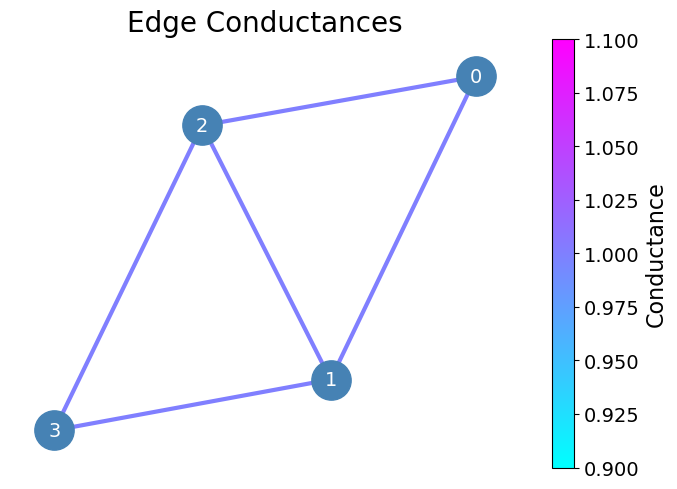

In [4]:
# Draw with edge weights
pos = nx.spring_layout(G, seed=42)
edge_labels = nx.get_edge_attributes(G, 'weight')

conductance = [G[u][v]['weight'] for u, v in G.edges()]
print("Edge conductances:", conductance)
# Set source and sink, imposed currents

Qin = np.zeros(L_weighted.shape[0])
Qin[source] = 1
Qin[sink] = -1     
print("Current injections Q_in:", Qin)

# Visualize conductances
plot_edge_property(G, pos, conductance, title='Edge Conductances', label='Conductance')


### Pseudo inverse of L
The system is Gauge invarient for the base pressure, meaning if $\bold{p}$ is a solution $L\bold {p}=\bold{Q}_{in}$, then $\bold{p} + q\bold{1}$ for scalar $q$, is also a solution. For the case of no external currents, the pressures should be $\bold{p}=\bold{0}$, but that yields that $\bold{1}=(1,1,..,1)^T$ is also a solution $L\bold{1}=\bold{0}$. Therefore, $\bold{1}$ is in the null space of $L$, so it is singular. 

$\Delta k_{ij} = -\alpha \frac{d L}{dk_{ij}}$

In [5]:


# solve for pressures using pseudoinverse of Laplacian
p = L_pinv @ Qin
p=p - p.min()  # Shift so min pressure is 0.

print("Pressures p (pseudoinverse):", np.round(p, 4))



Pressures p (pseudoinverse): [1.  0.5 0.5 0. ]


(5, 5) (5, 4) (4,)
Flows Q: [0.5 0.5 0.  0.5 0.5]


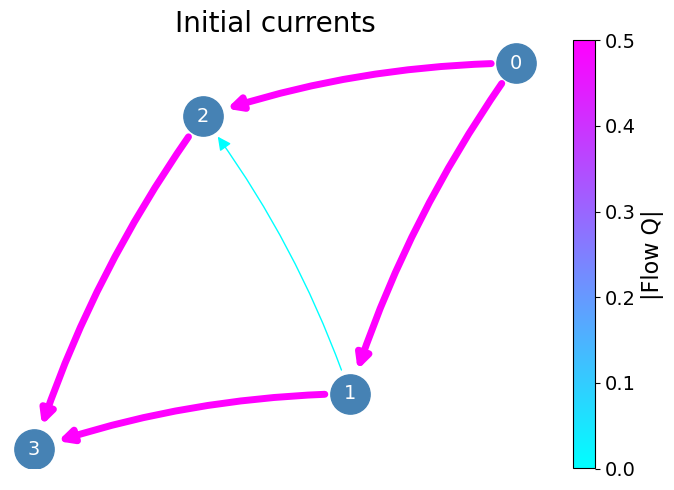

In [6]:
# now that the pressures are known, compute the flows on each edge as Q_ij = K_ij * (p_i - p_j)
print(np.shape(K), np.shape(B.T), np.shape(p))

Q = K @ B.T @ p
print("Flows Q:", np.round(Q, 4))
# Visualize currents

plot_edge_property(G, pos, Q, title='Initial currents', label='Flow Q', signed=True)


In [7]:
print("Edges:", list(G.edges()))
print("B.T:\n", B.T)
print("Pressures p:", p)
print("Flows I:", np.round(Q, 4))
print(K @ B.T)
print(Q)

Edges: [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)]
B.T:
 [[ 1. -1. -0. -0.]
 [ 1. -0. -1. -0.]
 [-0.  1. -1. -0.]
 [-0.  1. -0. -1.]
 [-0. -0.  1. -1.]]
Pressures p: [1.  0.5 0.5 0. ]
Flows I: [0.5 0.5 0.  0.5 0.5]
[[ 1. -1.  0.  0.]
 [ 1.  0. -1.  0.]
 [ 0.  1. -1.  0.]
 [ 0.  1.  0. -1.]
 [ 0.  0.  1. -1.]]
[5.00000000e-01 5.00000000e-01 1.11022302e-16 5.00000000e-01
 5.00000000e-01]


In [8]:
def conductance_update_rule(p_C,p_F, B, lr):
    """ Update the conductances according to d/dk(Power_dissipation_F - Power_dissipation_C)
    Power_dissipation_ij = (p_j - p_i^2) * K_ij
    => d/dk(Power_dissipation_ij) = (p_j - p_i^2)
    """
    dp_F = B.T @ p_F   # pressure drop across each edge, free phase
    dp_C = B.T @ p_C   # pressure drop across each edge, clamped phase

    delta_dp = dp_F**2 - dp_C**2
    return lr * delta_dp

def conductance_update_shear(Q_C,Q_F, K, lr):
    k = np.diag(K)
    dk = lr* k**2 * (Q_F - Q_C)
    return lr * dk


def get_graph_conductances_and_inverse_laplacian(G):
    """ Extract conductances and pressures from the graph """
    edges = list(G.edges())
    K_adj = np.diag([G[u][v]['weight'] for u, v in edges])
    
    L_weighted = nx.laplacian_matrix(G).toarray()
    L_pinv = np.linalg.pinv(L_weighted)
    return K_adj, L_pinv

def loss_function(Q, Q_goal):
    """ Simple squared error loss on the flow of a specific edge """
    return (Q - Q_goal)**2

In [9]:
# define learning constants
learning_rate = 0.001
loss_delta = 1e-5

# Target: we want to increase flow on edge (1,2)
# DeltaQ_C encodes the "nudge" toward the target
# target_edge_nodes = (1, 2)
target_current = 0.1  # desired flow on that edge
target_edge_idx = edges.index(target_edge_nodes)

Qin = np.zeros(L_weighted.shape[0])
Qin[source] = 1
Qin[sink] = -1     

G_init = copy.deepcopy(G)  # save initial state
G_current = copy.deepcopy(G)  # working copy for optimization

K, L_pinv = get_graph_conductances_and_inverse_laplacian(G_current)

In [10]:


# before optimization loop, compute the initial flow on the target edge
p = L_pinv @ Qin
p = p - p.min()  # Shift so min pressure is 0

Q_F = K @ B.T @ p

loss = loss_function(Q_F[target_edge_idx], target_current)
print(f"Target flow on edge {target_edge_nodes}: {target_current}, current flow: {Q_F[target_edge_idx]:.4f}, loss: {loss:.4f}")
print(f"original conductances: {[G[u][v]['weight'] for u, v in edges]}")

losses = [] 
history = []

ii = 0
dloss = 1
print(" === Starting optimization loop === ")
while loss > loss_delta: # and dloss > 1e-11:
# for ii in range(100000):
    # inject current accross the target edge to nudge flow in the right direction, add small current across it btween 
    Delta_Qin = learning_rate * loss
    Qin_C = Qin + Delta_Qin * (B[:, target_edge_idx])  # inject current across the target edge

    # CLAMPED CIRCUIT: solve pressures and currents, when forced to have more current on the target edge
    p_C = L_pinv @ Qin_C
    p_C = p_C - p_C.min()  # Shift so min pressure is 0
    Q_C = K @ B.T @ p_C
    # print(f"Clamped flow on edge {target_edge_nodes}: {Q_C[target_edge_idx]:.4f}, Delta_Q_in: {Delta_Q_in:.6f}, clamped pressures: {np.round(p_C, 4)}, free pressures: {np.round(p, 2)}")

    # ── Conductance update ─────────────────────────────────────────────
    # dk = conductance_update_rule(p_C, p, B, lr=1)
    dk = conductance_update_shear(Q_C, Q_F, K, lr=0.1)
    for e, (u, v) in enumerate(edges):
        G_current[u][v]['weight'] += dk[e]
        G_current[u][v]['weight'] = max(G_current[u][v]['weight'], 1e-4)  # prevent negative conductance   
    # print(f"Updated conductances: {[G[u][v]['weight'] for u, v in edges]}")

    # ── Rebuild network ────────────────────────────────────────────────
    K_curr, L_pinv_curr = get_graph_conductances_and_inverse_laplacian(G_current)

    # ── Free phase : solve pressures and currents with updated conductances ─────────────────────────
    p_F = L_pinv_curr @ Qin
    p_F = p_F - p_F.min()  # Shift so min pressure is 0
    Q_F = K_curr @ B.T @ p_F

    # print(f"edge {i}: ({u},{v})  |  Q={Q_F[i]:.5f}  |  k={G_current[u][v]['weight']:.5f}")
    old_loss = loss
    loss = loss_function(Q_F[target_edge_idx], target_current)
    losses.append(loss)
    dloss = np.abs(loss - old_loss)

    ii += 1
    if ii % 100 == 0:
        print(f"Iteration {ii}, target flow: {target_current}, current flow: {Q_F[target_edge_idx]:.5f}, loss: {loss:.6f}")
        history.append({
            'step': ii,
            'loss': loss,
            'conductances': [G_current[u][v]['weight'] for u, v in edges],
            'flows': Q_F.copy(),
            'pressures': p_F.copy()
        })

print(" === Optimization loop finished === ")


Target flow on edge (1, 2): 0.1, current flow: 0.0000, loss: 0.0100
original conductances: [1, 1, 1, 1, 1]
 === Starting optimization loop === 
Iteration 100, target flow: 0.1, current flow: 0.00000, loss: 0.010000
Iteration 200, target flow: 0.1, current flow: 0.00000, loss: 0.009999
Iteration 300, target flow: 0.1, current flow: 0.00001, loss: 0.009999
Iteration 400, target flow: 0.1, current flow: 0.00001, loss: 0.009998
Iteration 500, target flow: 0.1, current flow: 0.00001, loss: 0.009998
Iteration 600, target flow: 0.1, current flow: 0.00002, loss: 0.009997
Iteration 700, target flow: 0.1, current flow: 0.00002, loss: 0.009995
Iteration 800, target flow: 0.1, current flow: 0.00003, loss: 0.009994
Iteration 900, target flow: 0.1, current flow: 0.00004, loss: 0.009992
Iteration 1000, target flow: 0.1, current flow: 0.00006, loss: 0.009989
Iteration 1100, target flow: 0.1, current flow: 0.00007, loss: 0.009985
Iteration 1200, target flow: 0.1, current flow: 0.00010, loss: 0.009981
I

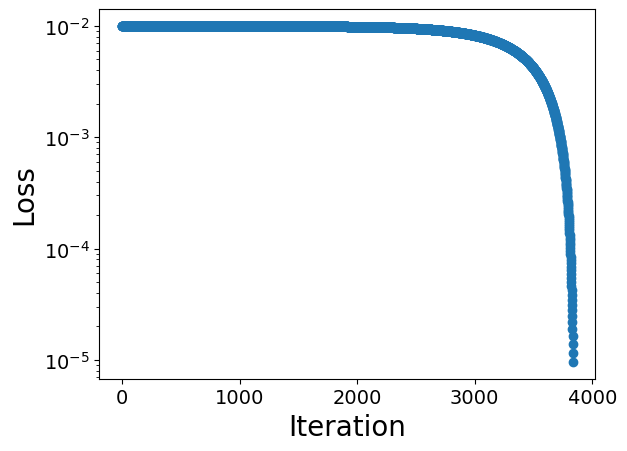

In [11]:
# plt.scatter(range(len(losses)), np.sqrt(losses))
plt.scatter(range(len(losses)), losses)
 # loss is defined as (Q-Q_goal)**2. plot also sqrt of that
plt.yscale('log')

# plot delta loss
# nploss = np.array(losses)
# plt.scatter(range(len(losses)-1),nploss[1::]-nploss[:-1])
# plt.scatter(range(len(losses)-1),losses[1::]-losses[::-1])
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.tick_params(labelsize=14)
plt.show()



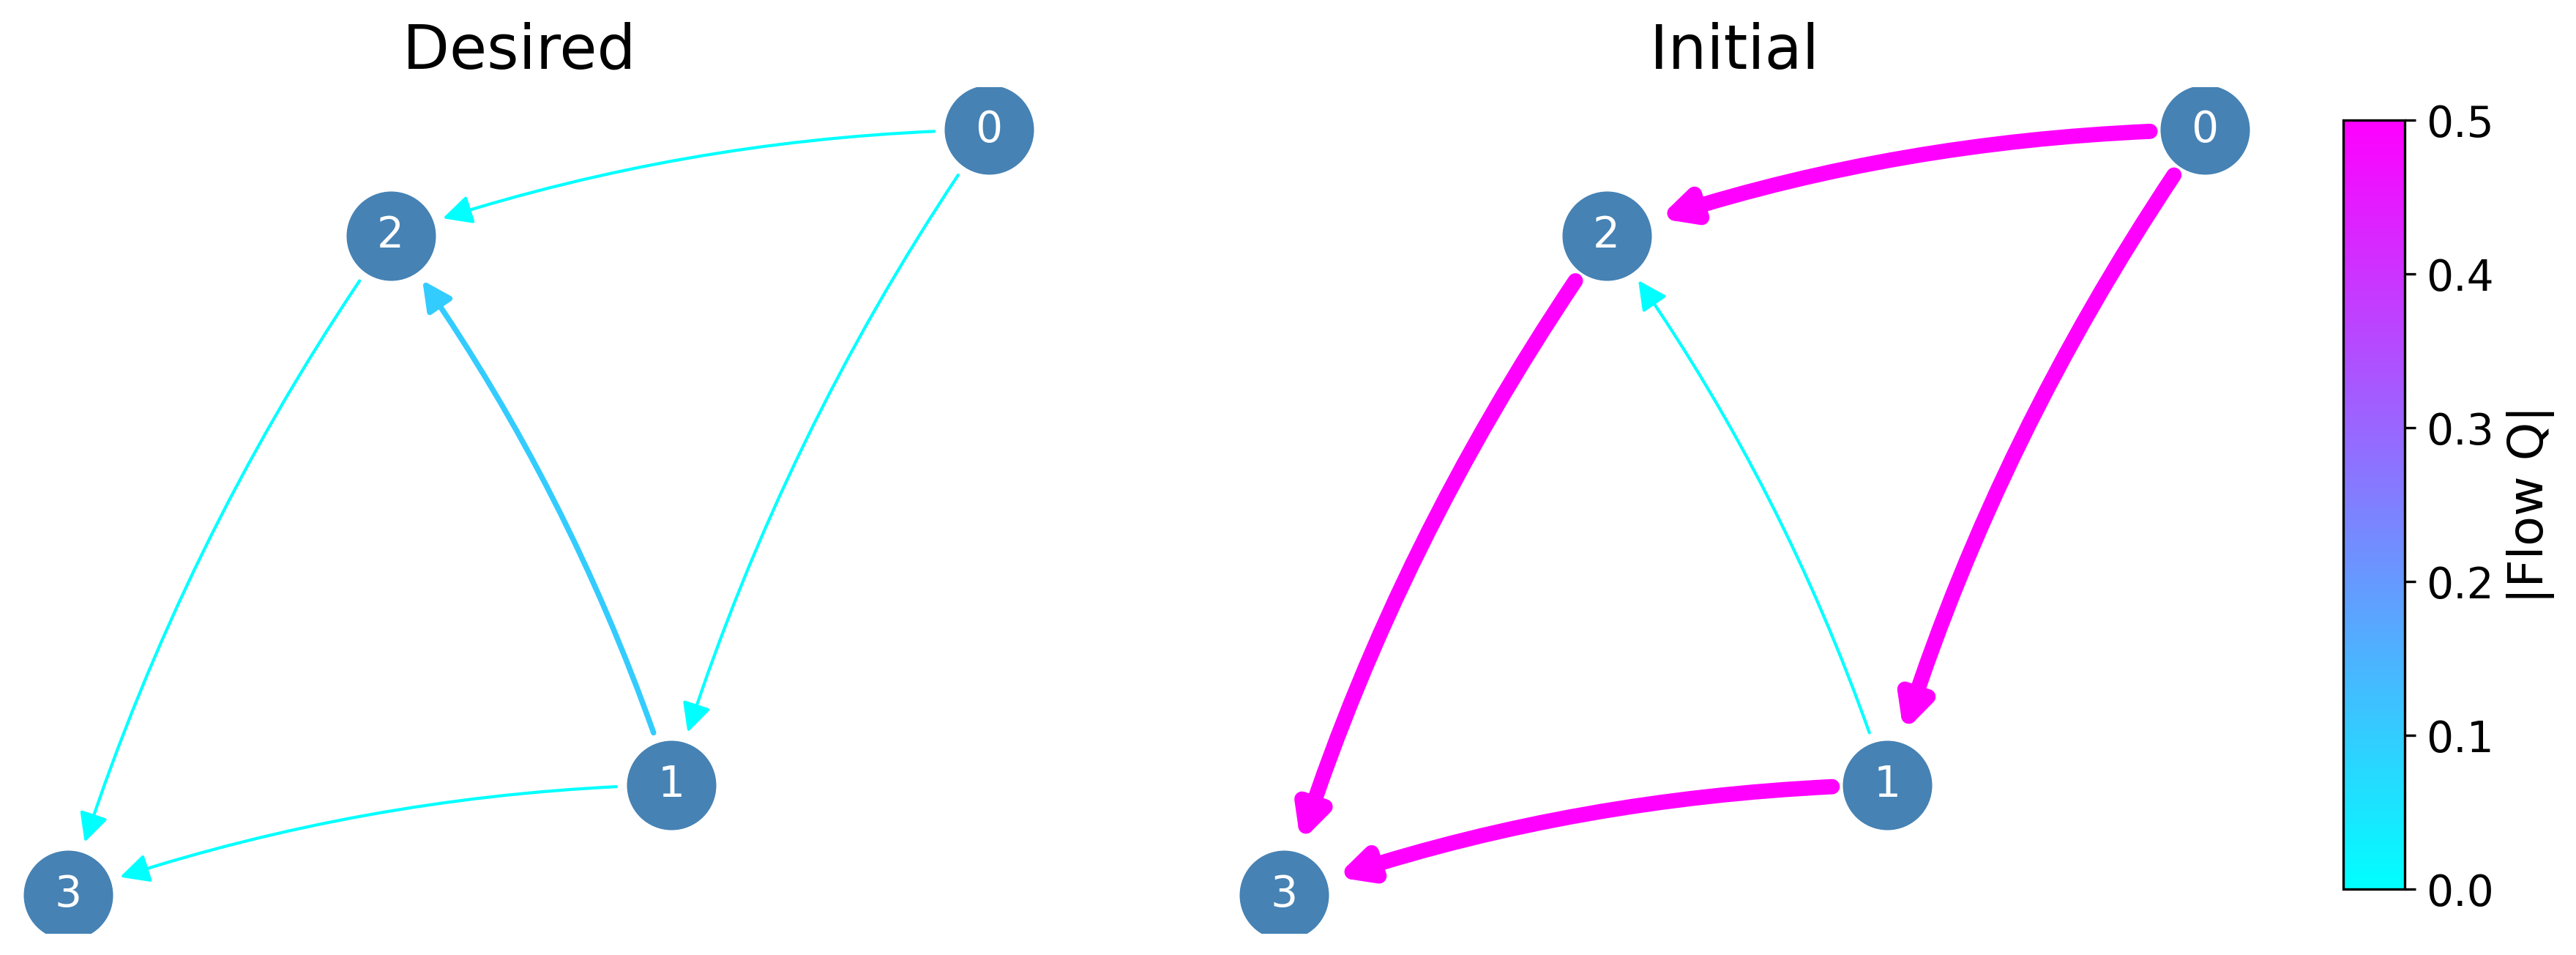

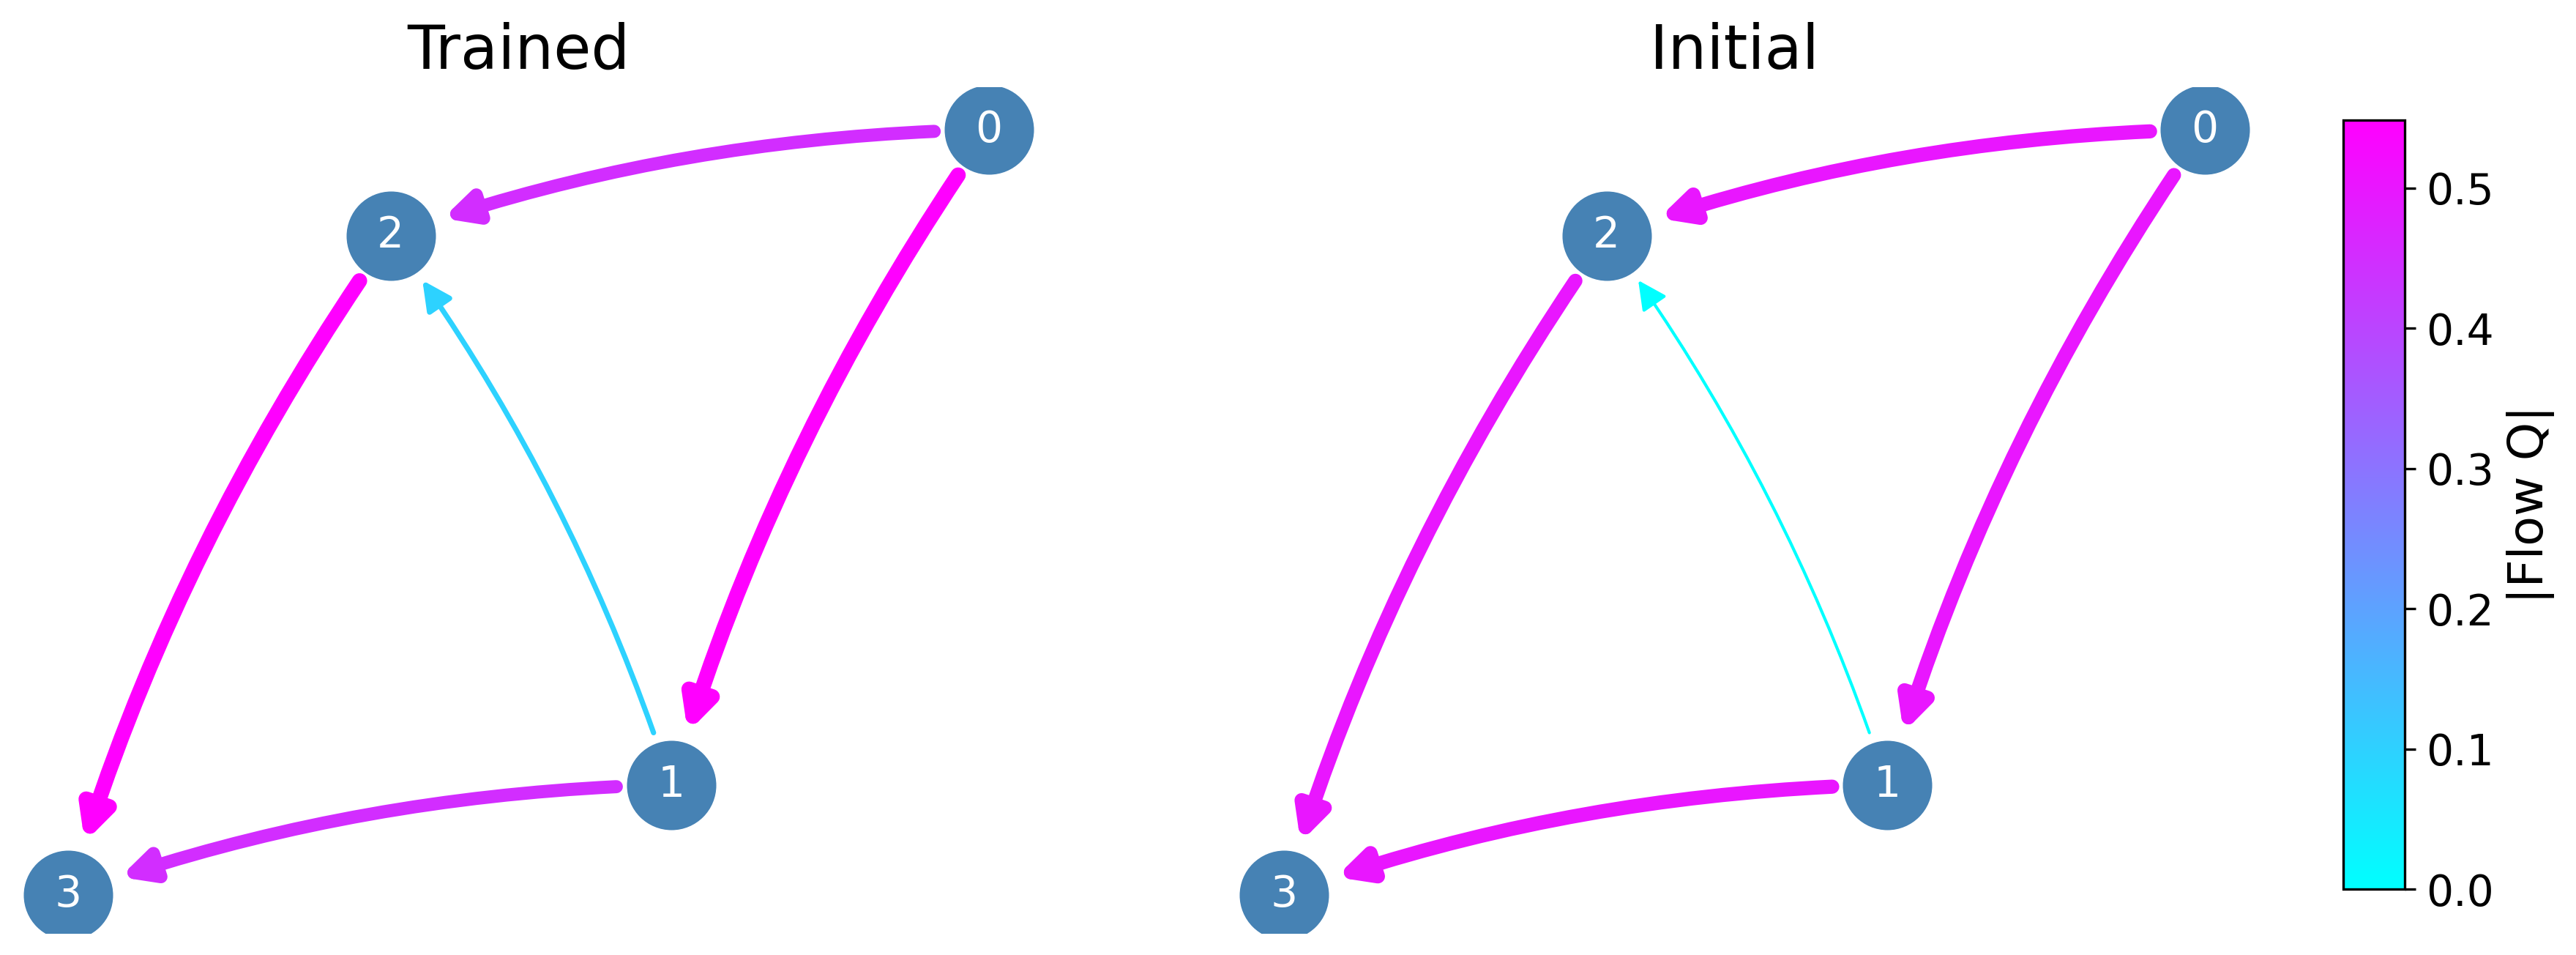

In [12]:
# plot initial network and the desired target flow
Q_desired = np.zeros_like(Q)
Q_desired[edges.index(target_edge_nodes)] = target_current  # Set desired flow on target edge
plot_before_after(
    G_current, G_init, pos,
    values_before=Q_desired, values_after=Q,
    title="",
    label='Flow Q',
    signed=True,
    subtitles=('Desired', 'Initial'),
)

# plot initial and trained currents (flows)
plot_before_after(
    G_init, G_current, pos,
    values_before=Q_F, values_after=Q,
    title="",
    label='Flow Q',
    signed=True,
    subtitles=('Trained', 'Initial'),
)

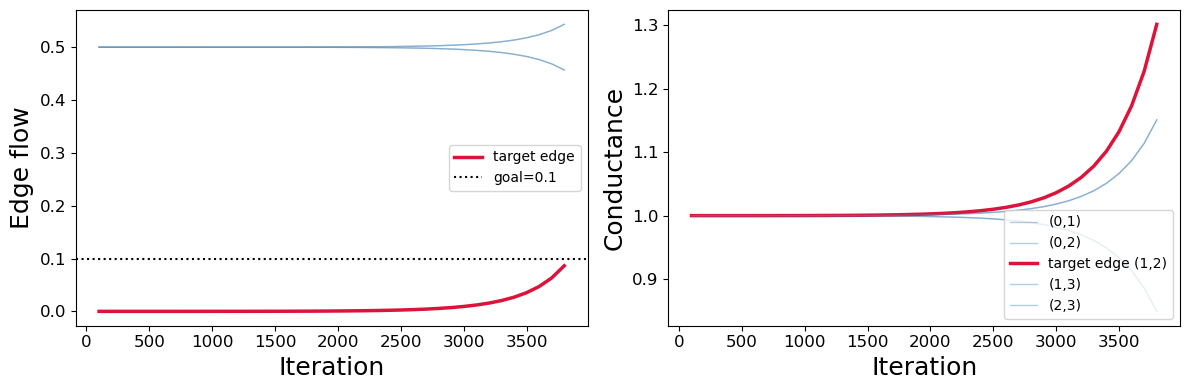

In [13]:
history_flows = np.array([h['flows'] for h in history])
history_steps = [h['step'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# All edge flows over time
for i, (u, v) in enumerate(edges):
    is_target = (u, v) == target_edge_nodes
    if is_target:
        axes[0].plot(history_steps, history_flows[:, i],
                     lw=2.5, ls='-', color='crimson',
                     label=f"target edge", zorder=5)
                    #  label=f"({u},{v}) target edge", zorder=5)
    else:
        axes[0].plot(history_steps, history_flows[:, i],
                     lw=1, color='steelblue', alpha=0.4) #, label=f"({u},{v})")
    # lw = 2.5 if (u, v) == target_edge_nodes else 1
    # ls = '-' if (u, v) == target_edge_nodes else '--'
    # axes[0].plot(history_steps, history_flows[:, i], label=f"({u},{v})", lw=lw, ls=ls)


font_size = 18
axes[0].tick_params(axis='both', which='major', labelsize=12)
axes[0].axhline(target_current, color='k', lw=1.5, ls=':', label=f"goal={target_current}")
axes[0].set_xlabel("Iteration", fontsize=font_size)
axes[0].set_ylabel("Edge flow", fontsize=font_size)
# axes[0].set_yscale('log'

# axes[0].set_title("Edge Flows over Training")
axes[0].legend()

# Conductance over time
history_conductances = [h['conductances'] for h in history]
axes[1].tick_params(axis='both', which='major', labelsize=12)
for i, (u, v) in enumerate(edges):
    if (u,v) == target_edge_nodes:
        axes[1].plot(history_steps, [h[i] for h in history_conductances], label=f"target edge ({u},{v})", lw=2.5, color='crimson')
    else:   
         axes[1].plot(history_steps, [h[i] for h in history_conductances], color='steelblue', alpha=0.4, label=f"({u},{v})", lw=1)
axes[1].set_xlabel("Iteration", fontsize=font_size)
axes[1].set_ylabel("Conductance", fontsize=font_size)
# axes[1].set_yscale('log')
# fix legend position
axes[1].legend(loc='lower right')

# # Loss over time
# history_losses = [h['loss'] for h in history]
# axes[2].tick_params(axis='both', which='major', labelsize=12)
# axes[2].scatter(history_steps, history_losses) #, color='tomato') #, linewidth=3)
# axes[2].set_xlabel("Iteration", fontsize=font_size)
# axes[2].set_ylabel("Loss", fontsize=font_size)
# axes[2].set_yscale('log')



plt.tight_layout()
plt.show()

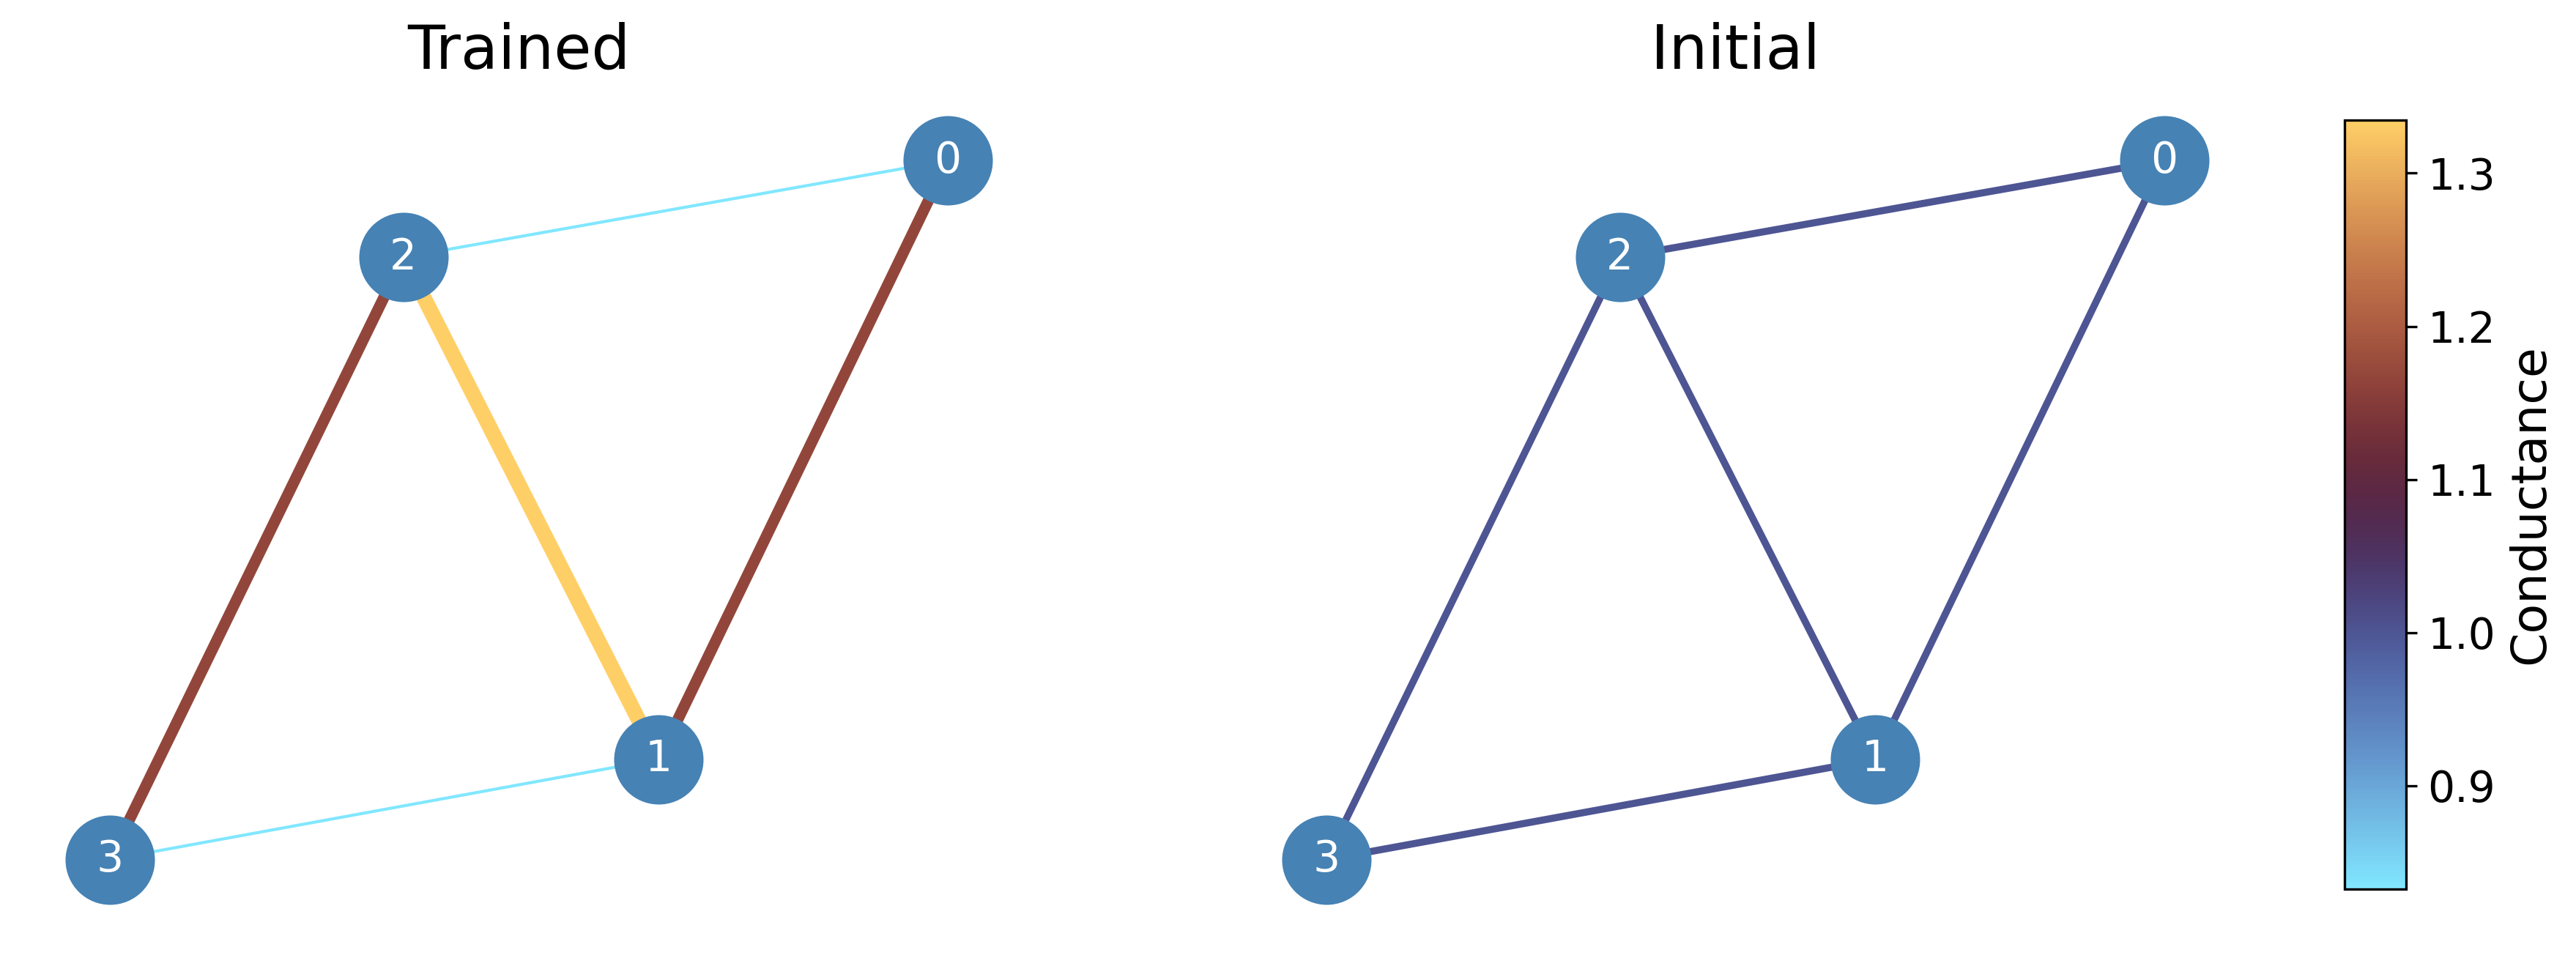

In [14]:
K_init, L_pinv_init = get_graph_conductances_and_inverse_laplacian(G)

plot_before_after(G_current, G_init, pos,
                  values_before=np.diag(K_curr),
                  values_after=np.diag(K_init),
                  title='', label='Conductance',
                  subtitles=('Trained', 'Initial'),
                  cmap=plt.cm.managua.reversed()) #, log_scale=True)

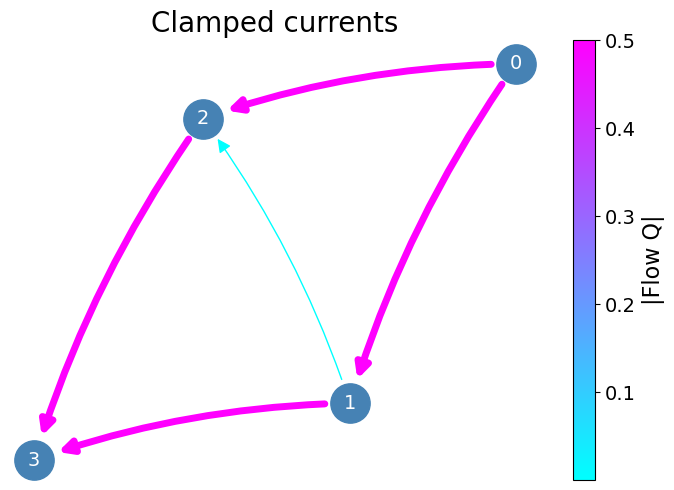

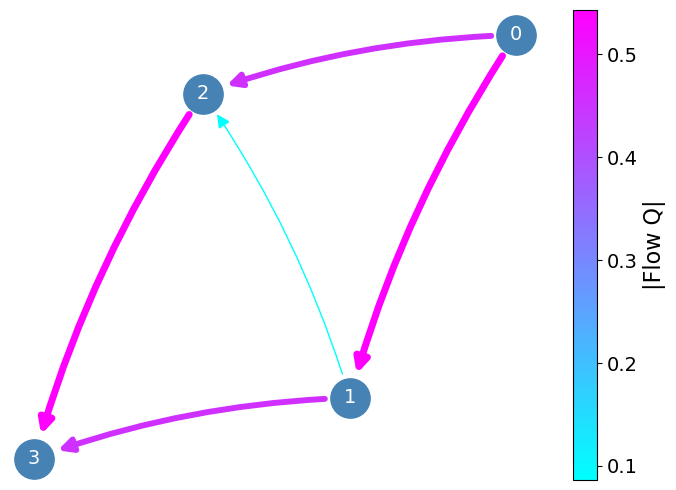

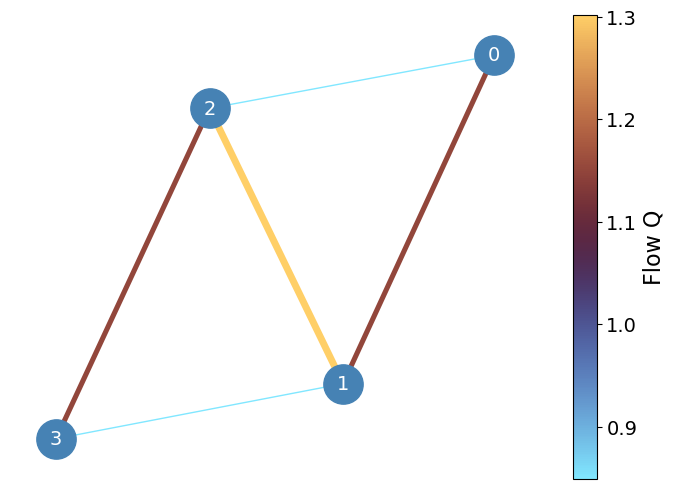

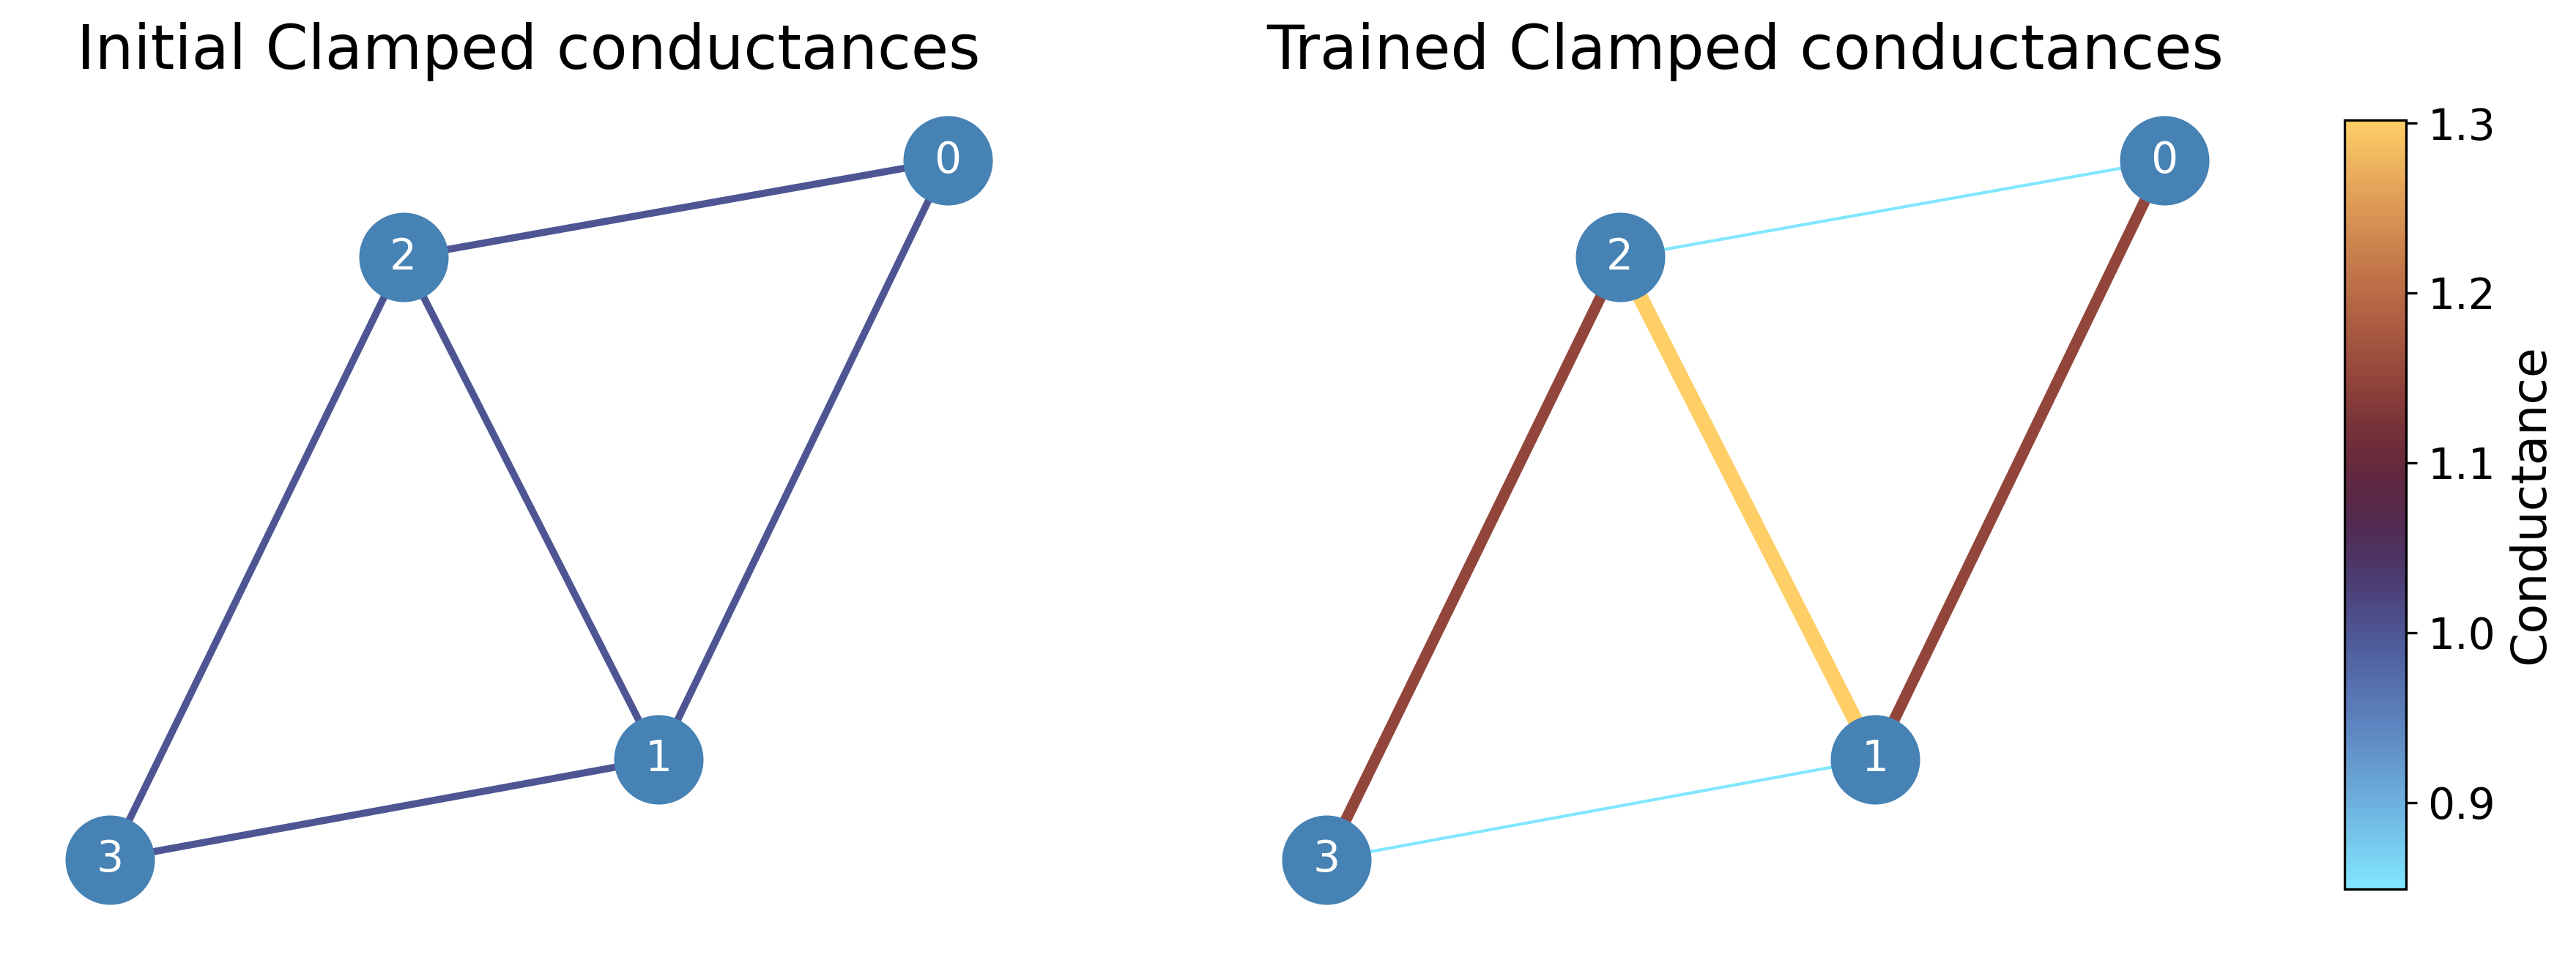

In [15]:
# visualize how adding some current across the target edge changes the pressures and flows in the clamped phase vs free phase, before any training has happened

# Qin_ex = Qin + 0.26 * (B[:, target_edge_idx])  # inject small current across the target edge`
# p_ex = L_pinv @ Qin_ex
# Q_ex = K @ B.T @ p_ex
plot_edge_property(G, pos, history_flows[15], title='Clamped currents', label='Flow Q', signed=True)

plot_edge_property(G, pos, history_flows[-1], title='', label='Flow Q', signed=True)
plot_edge_property(G, pos, history_conductances[-1], title='', label='Flow Q',cmap=plt.cm.managua.reversed())
plot_before_after(G, G_current, pos, history_conductances[15], history_conductances[-1], title='Clamped conductances', label='Conductance', cmap=plt.cm.managua.reversed())

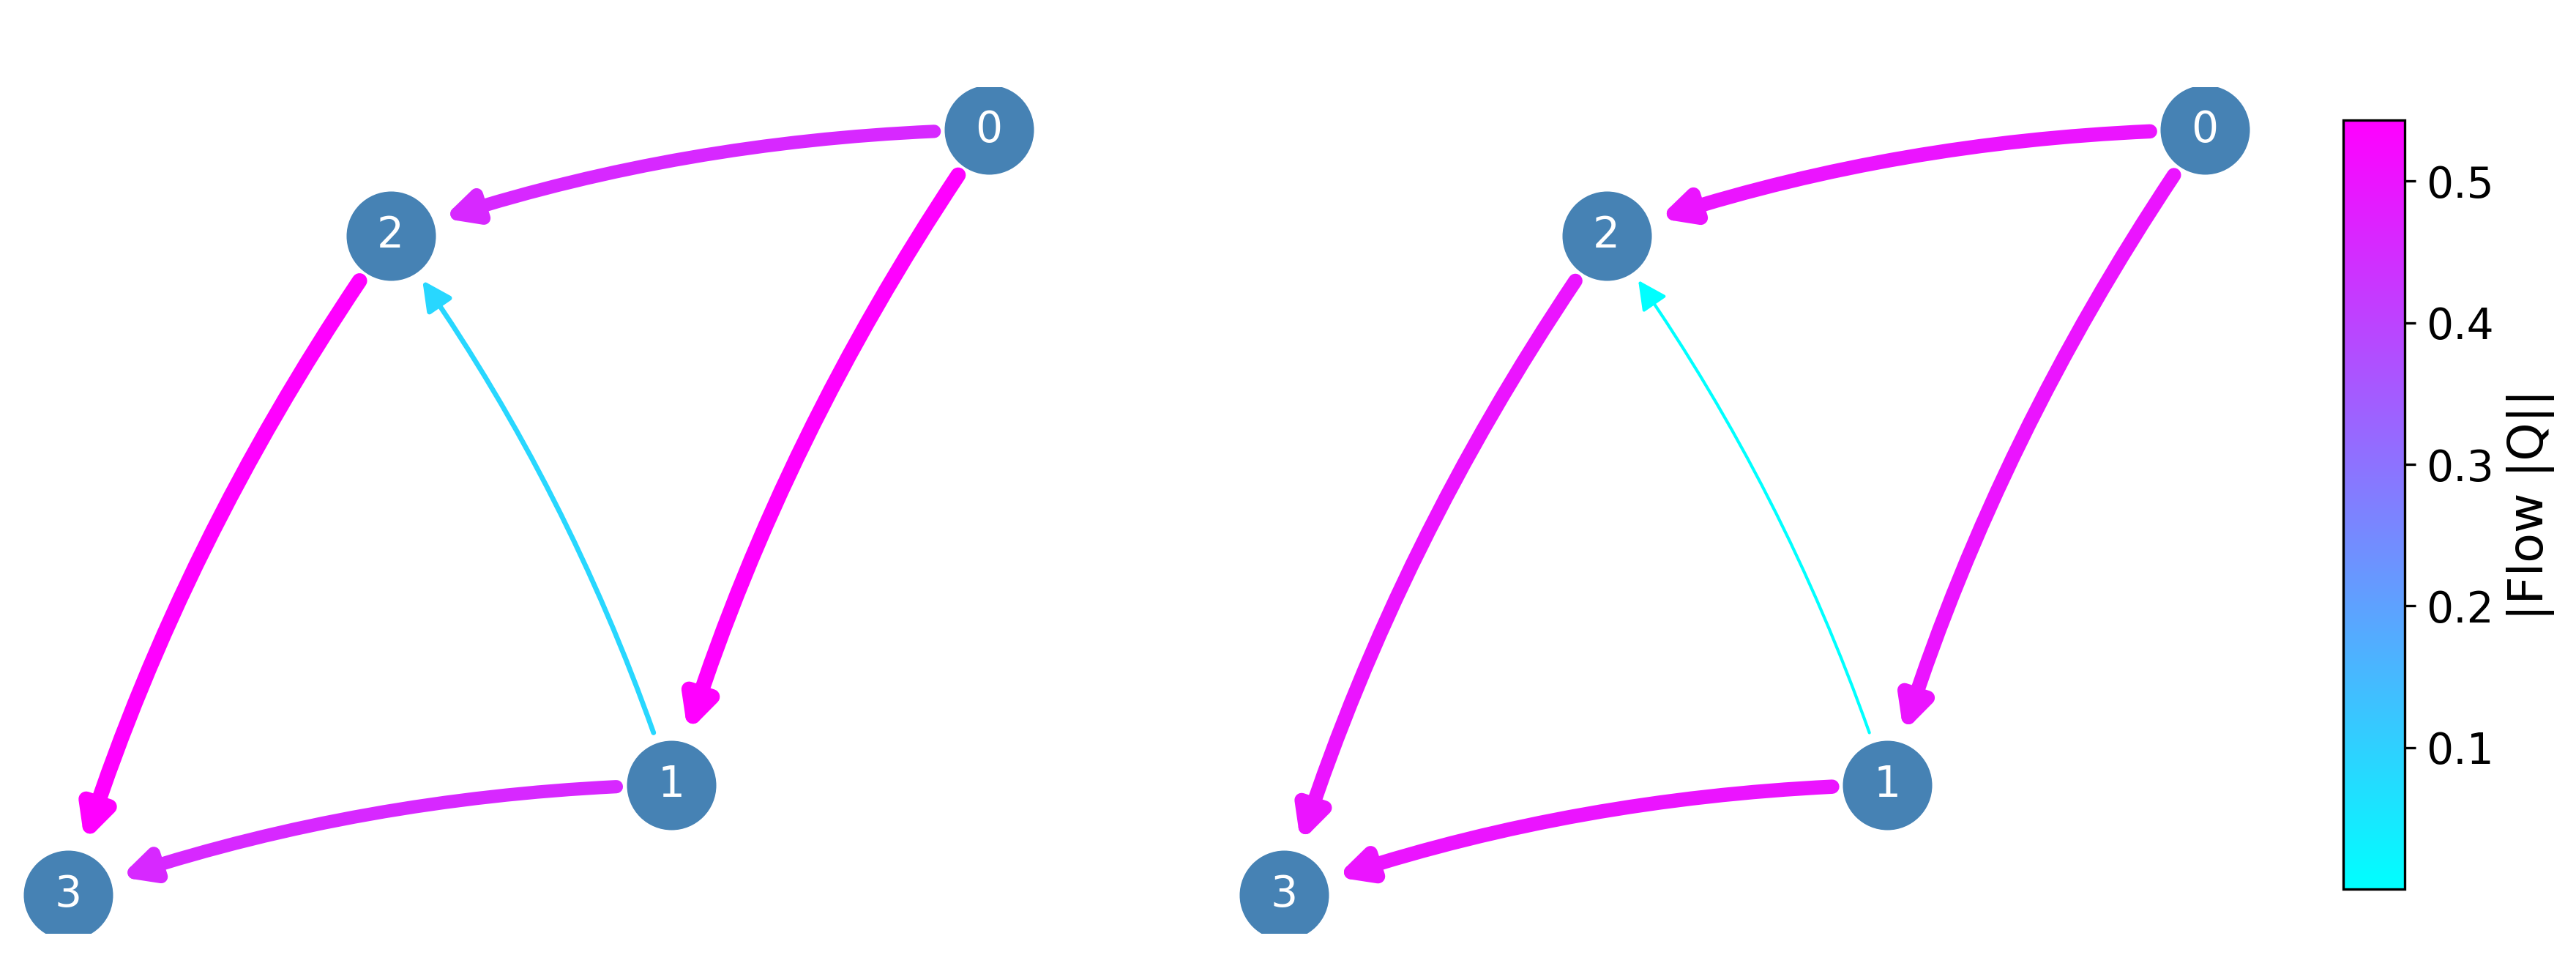

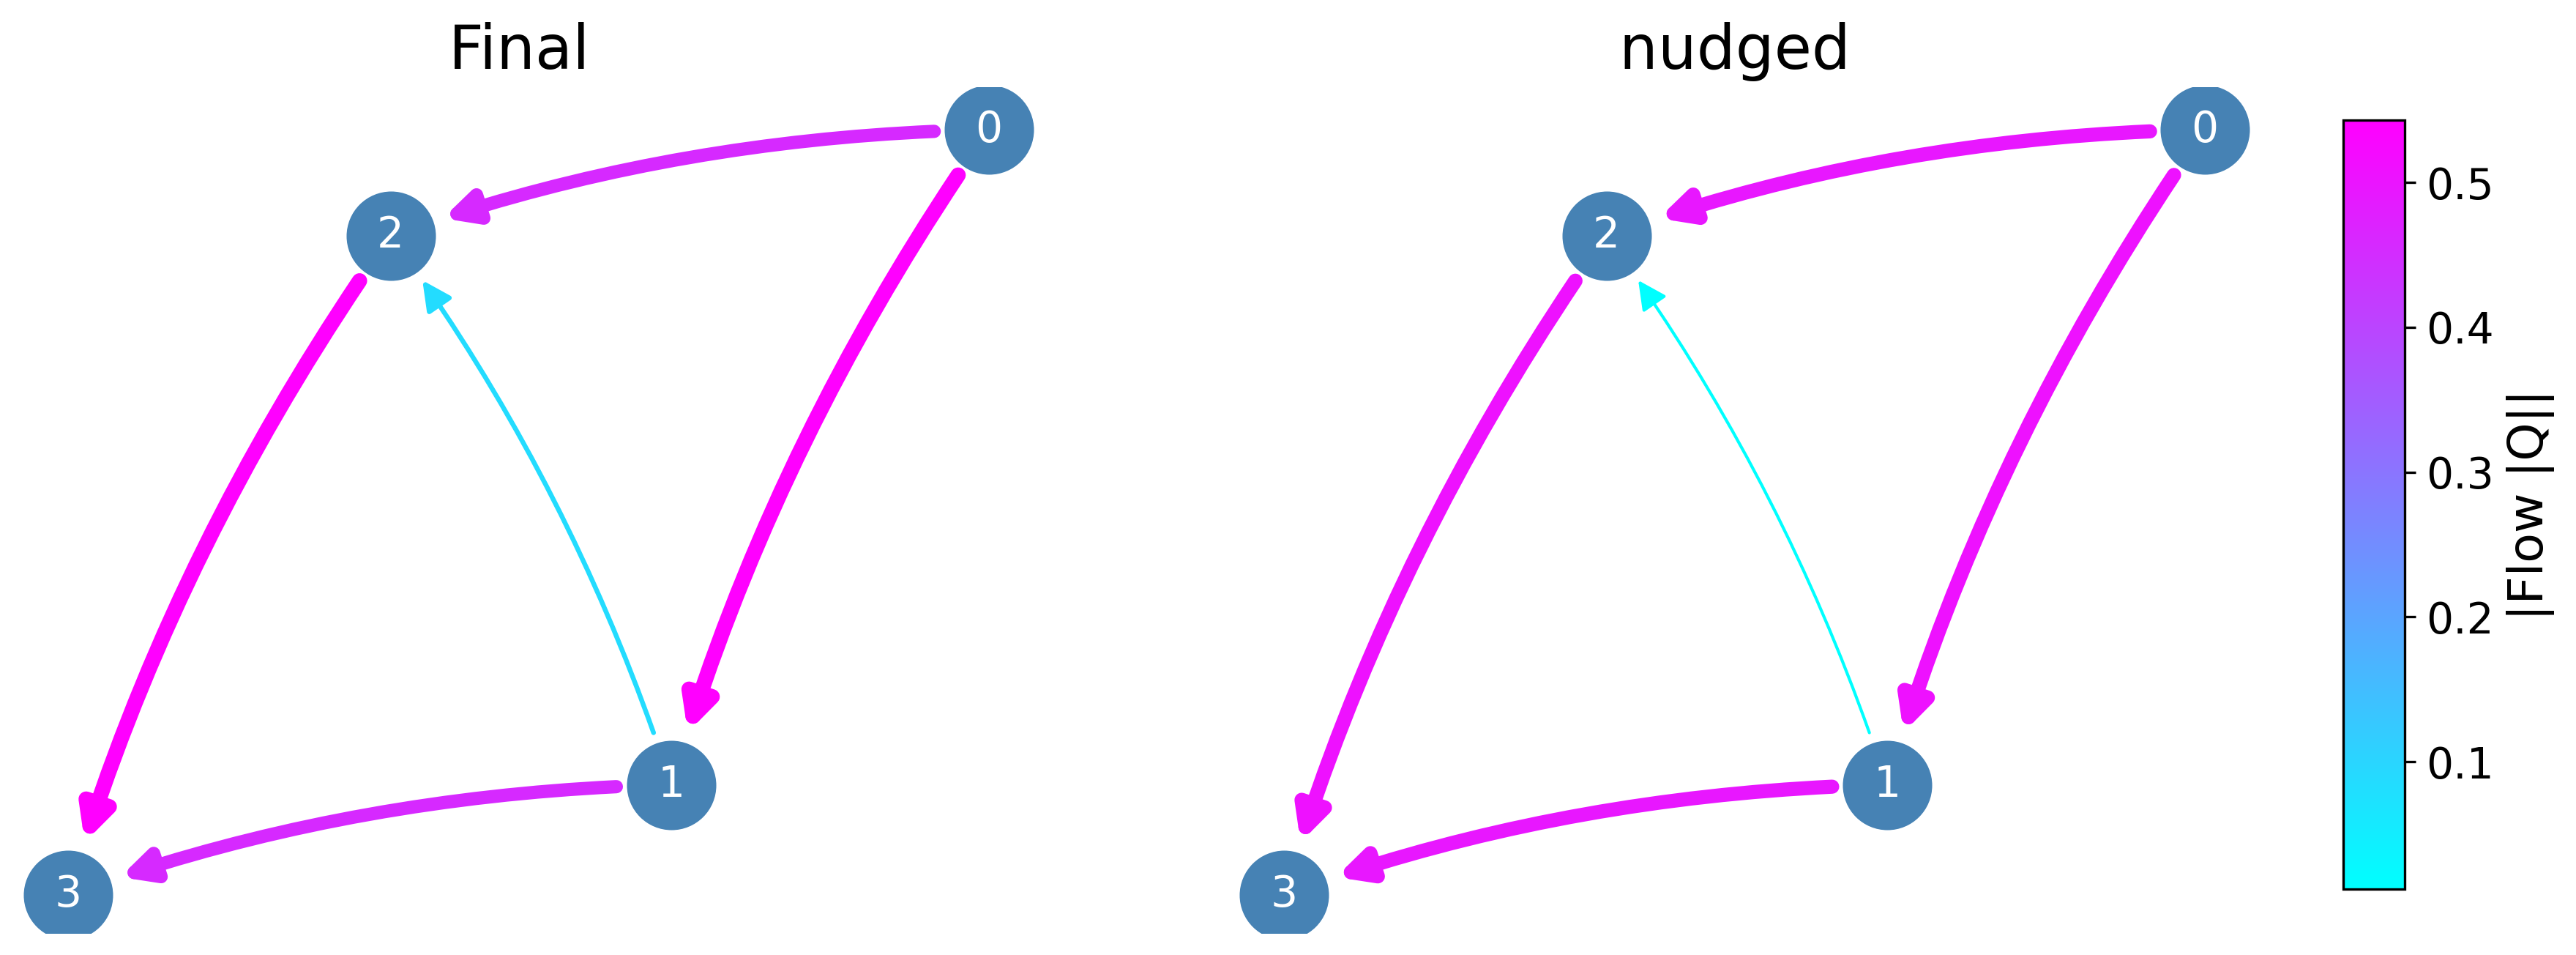

In [16]:
# Flows — diverging, can be positive or negative
plot_before_after(G_init, G_current, pos,
                  history_flows[-1,:],
                  history_flows[1,:],  # initial flows
                    # final flows
                  title='', label='Flow |Q|',
                  subtitles=('', ''),
                  cmap=plt.cm.cool, signed=True)
plot_before_after(G_init, G_current, pos,
                  history_flows[-1,:],
                  history_flows[30,:],  # initial flows
                    # final flows
                  title='', label='Flow |Q|',
                  subtitles=('Final', 'nudged'),
                  cmap=plt.cm.cool, signed=True)

L(k_ij)*p_c=Q_in
k_ij(p_j-p_i)=Q
Q=k_ij(p_j-p_i)

In [17]:
history_flows[0,:]
history_flows[-1,:]

array([0.54313708, 0.45686292, 0.08627417, 0.45686291, 0.54313709])

In [18]:
def plot_training_trajectories(
    history, edges, target_edge_nodes, target_current,
    font_size=18, tick_size=14,
):
    history_steps        = [h['step']         for h in history]
    history_flows        = np.array([h['flows']        for h in history])
    history_conductances = np.array([h['conductances'] for h in history])

    TARGET_COLOR = 'crimson'
    OTHER_COLOR  = '#999999'
    OTHER_ALPHA  = 0.6
    OTHER_LW     = 0.8
    TARGET_LW    = 2.5

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=200)

    for ax, data, ylabel, goal, goal_label in [
        (axes[0], history_conductances, 'Conductance', None,           None),
        (axes[1], history_flows,        'Flow',        target_current, f'goal = {target_current}'),
    ]:
        # background: all other edges
        for i, (u, v) in enumerate(edges):
            if (u, v) != target_edge_nodes:
                ax.plot(history_steps, data[:, i],
                        color=OTHER_COLOR, alpha=OTHER_ALPHA, lw=OTHER_LW, zorder=1, label='other edges' if i == 0 else None)

        # target edge on top
        t_idx = next(i for i, e in enumerate(edges) if e == target_edge_nodes)
        ax.plot(history_steps, data[:, t_idx],
                color=TARGET_COLOR, lw=TARGET_LW, zorder=3, label='target edge')

        if goal is not None:
            ax.axhline(goal, color='k', lw=1.5, ls=':', zorder=2, label=goal_label)

        ax.set_xlabel('Iteration', fontsize=font_size)
        ax.set_ylabel(ylabel,      fontsize=font_size)
        ax.tick_params(axis='both', labelsize=tick_size)
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(fontsize=font_size*0.65, frameon=False, loc='upper left')

    plt.tight_layout()
    plt.show()


def plot_loss_trajectory(
    history, font_size=22, tick_size=14, annotations=None, log_scale=False
):
    """
    Slide 2: loss curve with optional annotations.

    Parameters
    ----------
    history     : list of dicts with keys 'step', 'loss'
    annotations : list of dicts with keys 'step', 'text', and optionally 'y_offset'.
                  Example:
                    [{'step': 50,  'text': 'routing clicks'},
                     {'step': 200, 'text': 'plateau breaks'}]
    """
    steps  = [h['step'] for h in history]
    losses = [h['loss'] for h in history]

    fig, ax = plt.subplots(figsize=(7, 4), dpi=200)

    ax.scatter(steps, losses, color='steelblue')
    ax.set_xlabel('Iteration', fontsize=font_size)
    ax.set_ylabel('Loss',      fontsize=font_size)
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.spines[['top', 'right']].set_visible(False)
    if log_scale:
        ax.set_yscale('log')

    if annotations:
        y_min, y_max = ax.get_ylim()
        y_range      = y_max - y_min
        for ann in annotations:
            s        = ann['step']
            text     = ann['text']
            y_offset = ann.get('y_offset', 0.1 * y_range)
            # find loss value at that step
            idx = min(range(len(steps)), key=lambda i: abs(steps[i] - s))
            y   = losses[idx]
            ax.annotate(
                text,
                xy=(s, y), xytext=(s, y + y_offset),
                arrowprops=dict(arrowstyle='->', color='k', lw=1.2),
                fontsize=12, ha='center',
            )
            ax.axvline(s, color='gray', lw=1, ls='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

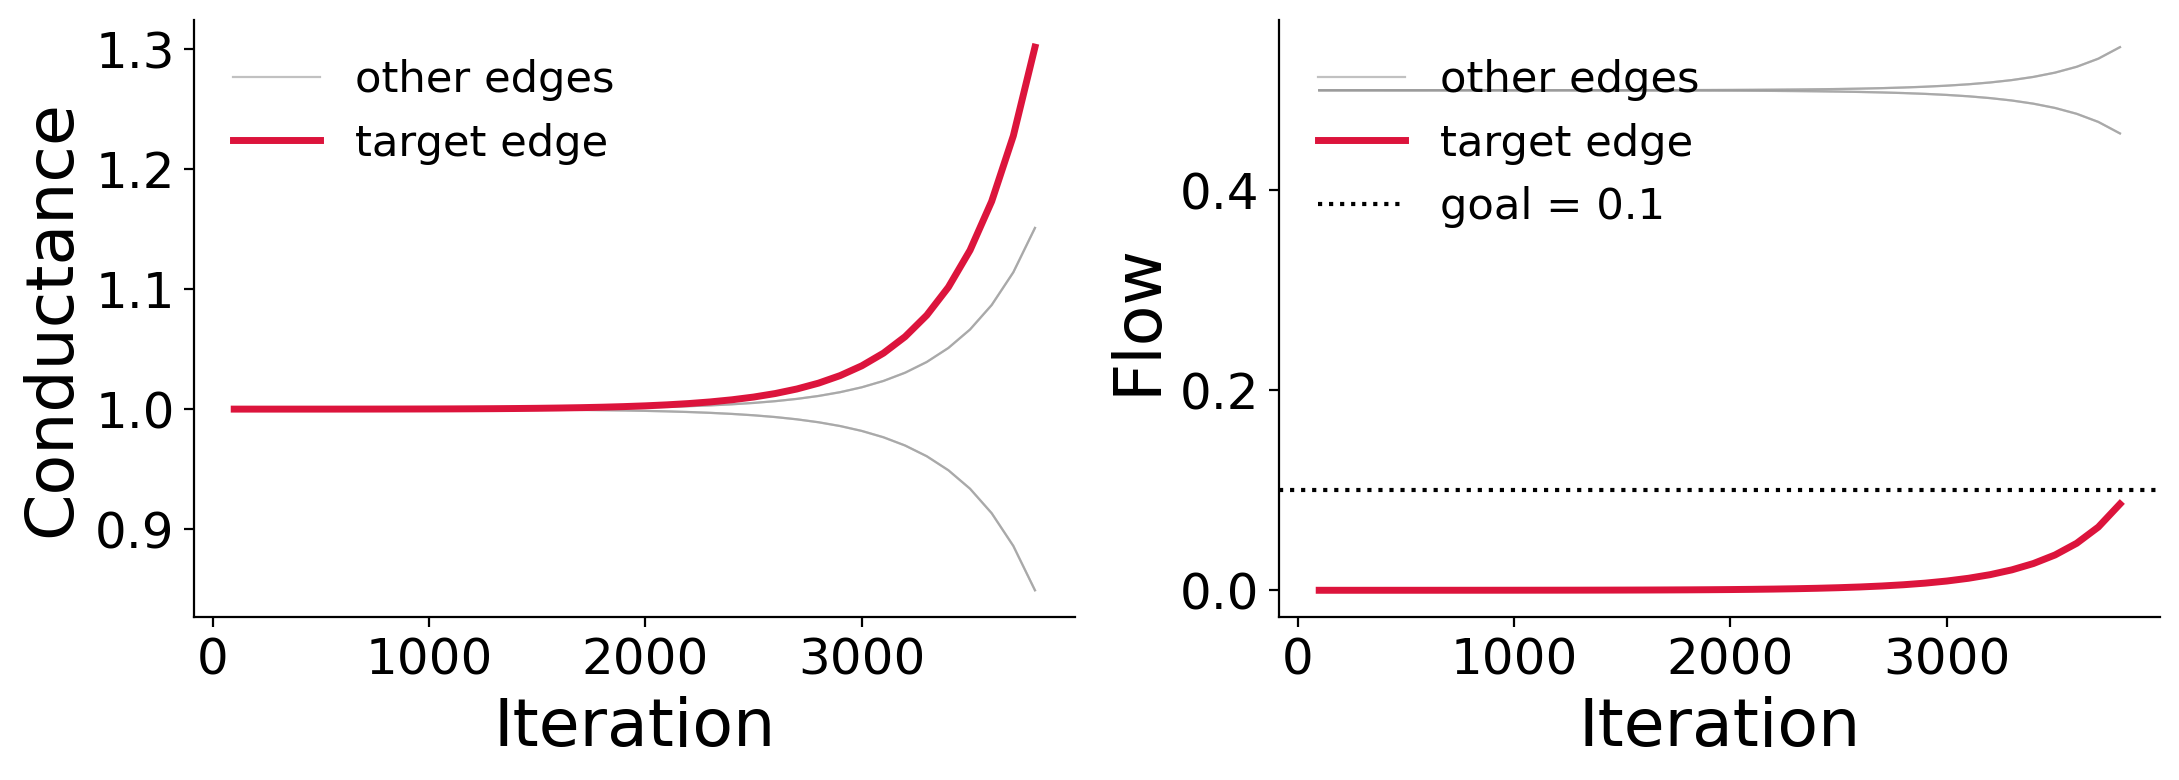

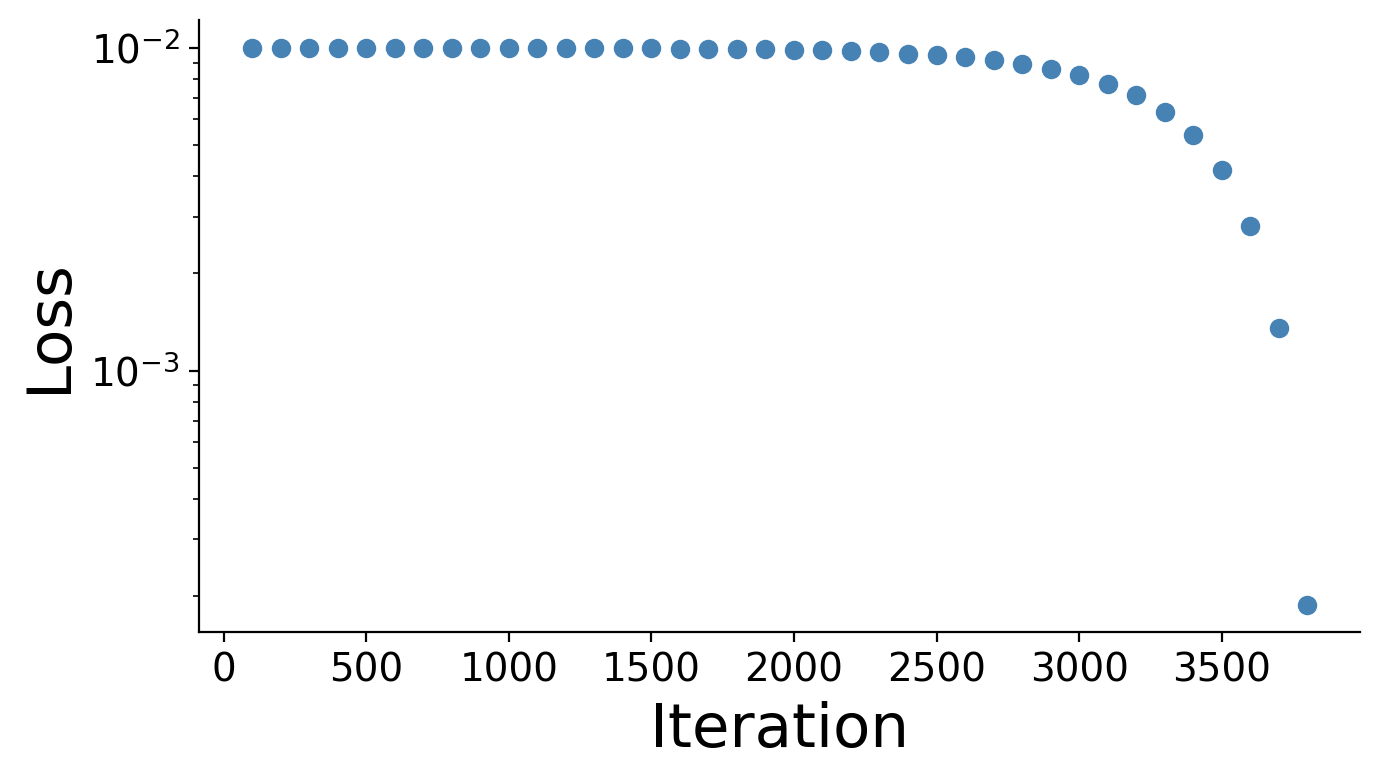

/tmp/ipykernel_58945/1537938403.py:90: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


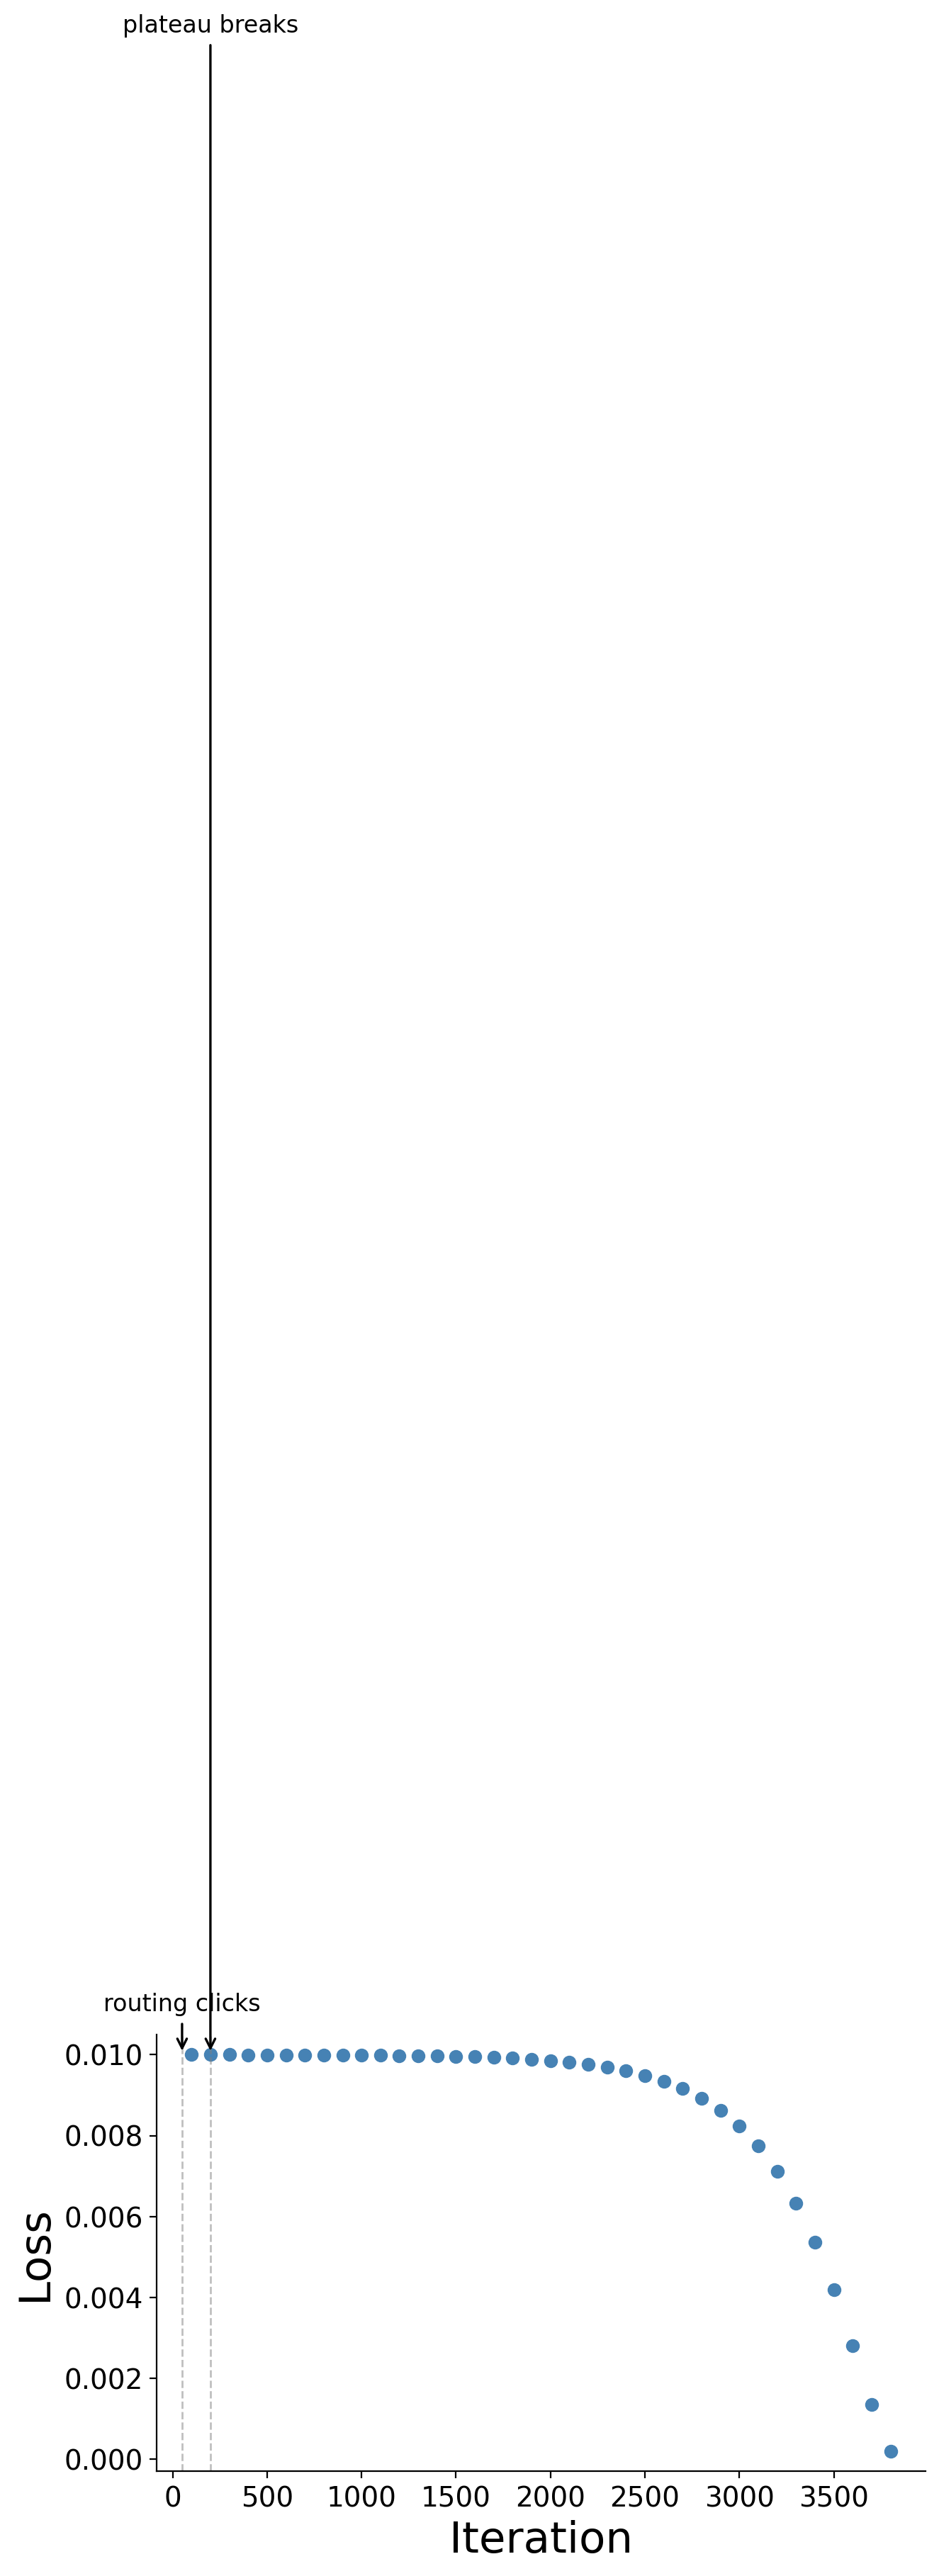

In [19]:
# Slide 1
plot_training_trajectories(
    history, edges, target_edge_nodes, target_current, font_size=24,tick_size=18
)

# Slide 2 — bare
plot_loss_trajectory(history, font_size=22, log_scale=True)

# Slide 2 — with annotations if the curve has interesting structure
plot_loss_trajectory(history, annotations=[
    {'step': 50,  'text': 'routing clicks'},
    {'step': 200, 'text': 'plateau breaks', 'y_offset': 0.05},
])